# Neuromorphic SNN for Energy-Efficient Anomaly Detection

**Architecture**: SNN Autoencoder (SpikingJelly LIF) vs ANN + classical baselines
**Datasets**: Thyroid (ODDS), Cardiotocography (ODDS), NSL-KDD, SMAP-proxy

**Research contributions**:
1. T-sensitivity Pareto frontier -- accuracy vs projected energy across T in {4,8,16,32}
2. Per-layer spike sparsity analysis -- mechanistic explanation of energy efficiency
3. Honest energy framing -- GPU-actual (ANN) vs Loihi-2-projected (SNN)
4. Multi-seed statistical evaluation -- 5 seeds, mean +/- std reported
5. Classical baseline comparison -- OCSVM, IsolationForest, LOF

---
Run **Cell 0** once per VSCode session to set paths and verify GPU.

In [1]:
# ── Fix for c10.dll initialization on Windows ───────────────────────────────
import os
import platform
if platform.system() == "Windows":
    import ctypes
    from importlib.util import find_spec
    try:
        if (spec := find_spec("torch")) and spec.origin:
            dll_path = os.path.join(os.path.dirname(spec.origin), "lib", "c10.dll")
            if os.path.exists(dll_path):
                ctypes.CDLL(os.path.normpath(dll_path))
    except Exception:
        pass
# ───────────────────────────────────────────────────────────────────────────

In [ ]:
# Needs to be fixed ASAP!!!

# CELL 0 -- Local Setup  (RTX 4070, VSCode Jupyter kernel)

import os, sys
from pathlib import Path

# ── Project root = wherever this notebook lives ──────────────────────────────
# __file__ is not defined in notebooks, so we resolve from the notebook path.
# If this gives the wrong directory, hard-code the path below.
try:
    PROJECT_ROOT = Path(globals()['__vsc_ipynb_file__']).parent.resolve()
except KeyError:
    # Fallback: hard-code your project root
    PROJECT_ROOT = Path(r'C:/Capstone/Experiment SNN-Abnormality-Detection')

DATA_DIR    = PROJECT_ROOT / 'data'
RESULTS_DIR = PROJECT_ROOT / 'results'
DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Add project root to path so 'src' imports work
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)

# Convert to strings for code that expects str not Path
DATA_DIR    = str(DATA_DIR)
RESULTS_DIR = str(RESULTS_DIR)

# ── Verify GPU ────────────────────────────────────────────────────────────────
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
if DEVICE == 'cuda':
    props = torch.cuda.get_device_properties(0)
    vram  = props.total_memory / 1024**3
    print(f'GPU      : {props.name}')
    print(f'VRAM     : {vram:.1f} GB')
    if vram < 6:
        print('WARNING  : Less than 6 GB VRAM -- reduce batch_size in Cell 5 if OOM')
else:
    print('WARNING  : No CUDA GPU found. Training will be slow on CPU.')
    print('           Check: nvidia-smi  and  torch.cuda.is_available()')

print(f'\nProject  : {PROJECT_ROOT}')
print(f'Data     : {DATA_DIR}')
print(f'Results  : {RESULTS_DIR}')
print('\nSetup complete. Proceed to Cell 1.')

PyTorch  : 2.6.0+cu124
Device   : cuda
GPU      : NVIDIA GeForce RTX 4070 Laptop GPU
VRAM     : 8.0 GB

Project  : C:\Capstone\Experiment SNN-Abnormality-Detection
Data     : C:\Capstone\Experiment SNN-Abnormality-Detection\data
Results  : C:\Capstone\Experiment SNN-Abnormality-Detection\results

Setup complete. Proceed to Cell 1.


In [3]:
# CELL 1 -- Imports
import numpy as np
import torch
import matplotlib.pyplot as plt
import json
from pathlib import Path
from functools import partial

from src.models.snn_autoencoder import SNNAutoencoder
from src.models.ann_autoencoder import ANNAutoencoder
from src.models.baselines import run_all_baselines
from src.data.loader import DataManager
from src.evaluation.trainer import train
from src.evaluation.metrics import (
    multi_seed_evaluate, print_comparison,
    reconstruction_errors, optimal_threshold, detection_metrics,
)
from src.evaluation.visualise import (
    plot_training_loss, plot_error_distributions,
    plot_comparison, plot_t_sensitivity, plot_sparsity,
)
from src.neuromorphic.lif_neuron import demo as lif_demo

print('All imports successful')

All imports successful


In [ ]:
# CELL 2 -- Smoke test
# Verifies imports + one forward pass SNN/ANN + metrics pipeline.
# Takes ~15-30 seconds. If this passes, the full experiment will run.

print('Running smoke test...\n')
errors = []

rng = np.random.RandomState(0)
X_smoke = rng.randn(200, 10).astype(np.float32)
y_smoke = np.zeros(200, dtype=np.float32)
y_smoke[:20] = 1.0

dm_smoke = DataManager(data_dir=DATA_DIR)
X_tr, X_te, y_te = dm_smoke.split(X_smoke, y_smoke, test_size=0.2)
tr_ld, te_ld = dm_smoke.dataloaders(X_tr, X_te, batch_size=32)
print(f'[1] DataManager split OK  (train={len(X_tr)}, test={len(X_te)})')

try:
    snn_s = SNNAutoencoder(input_dim=10, hidden_dim=16, latent_dim=4, T=4).to(DEVICE)
    sample = torch.tensor(X_tr[:8]).to(DEVICE)
    out = snn_s(sample)
    assert out.shape == sample.shape
    synops = snn_s.count_synops(sample)
    rates  = snn_s.spike_rates(sample)
    print(f'[2] SNN forward OK  (SynOps={synops["synops_per_sample"]:.1f}, '
          f'enc_hidden={rates["enc_hidden"]:.1%})')
except Exception as e:
    errors.append(f'SNN: {e}')
    print(f'[2] SNN FAILED: {e}')

try:
    ann_s = ANNAutoencoder(input_dim=10, hidden_dim=16, latent_dim=4).to(DEVICE)
    out_a = ann_s(sample)
    assert out_a.shape == sample.shape
    flops = ann_s.count_flops(sample)
    print(f'[3] ANN forward OK  (FLOPs={flops["flops_per_sample"]:.0f})')
except Exception as e:
    errors.append(f'ANN: {e}')
    print(f'[3] ANN FAILED: {e}')

try:
    snn_t = SNNAutoencoder(input_dim=10, hidden_dim=16, latent_dim=4, T=4).to(DEVICE)
    losses = train(snn_t, tr_ld, DEVICE, epochs=2, lr=1e-3, log_every=2, is_snn=True)
    assert len(losses) == 2
    print(f'[4] Training loop OK  (loss={losses[-1]:.4f})')
except Exception as e:
    errors.append(f'Train: {e}')
    print(f'[4] Training FAILED: {e}')

try:
    tr_err = reconstruction_errors(snn_t, tr_ld, DEVICE)
    te_err = reconstruction_errors(snn_t, te_ld, DEVICE)
    thresh = optimal_threshold(tr_err)
    det    = detection_metrics(te_err, y_te, thresh)
    print(f'[5] Metrics OK  (F1={det["f1"]:.4f}, AUC={det["auc"]:.4f})')
except Exception as e:
    errors.append(f'Metrics: {e}')
    print(f'[5] Metrics FAILED: {e}')

try:
    from src.models.baselines import BaselineDetector
    br = BaselineDetector('IsoForest').fit(X_tr).evaluate(X_te, y_te)
    print(f'[6] Baseline OK  (IsoForest F1={br["f1"]:.4f})')
except Exception as e:
    errors.append(f'Baseline: {e}')
    print(f'[6] Baseline FAILED: {e}')

try:
    from src.neuromorphic.lif_neuron import LIFNeuron
    spikes = LIFNeuron(tau=5.0).simulate([0.3]*20)
    print(f'[7] LIF neuron OK  (spikes={sum(spikes)}/20)')
except Exception as e:
    errors.append(f'LIF: {e}')
    print(f'[7] LIF FAILED: {e}')

print()
if not errors:
    print('All smoke tests passed -- safe to run the full experiment.')
else:
    print(f'{len(errors)} test(s) failed -- fix before running Cell 5+')
    for e in errors:
        print(f'  {e}')

Running smoke test...

  Train :   144 normal only
  Test  :    36 normal +    20 anomaly
[1] DataManager split OK  (train=144, test=56)
[2] SNN forward OK  (SynOps=28.5, enc_hidden=11.1%)
[3] ANN forward OK  (FLOPs=448)
  Epoch    1/2  loss=1.272481
  Epoch    2/2  loss=1.256101
[4] Training loop OK  (loss=1.2561)
[5] Metrics OK  (F1=0.0000, AUC=0.5861)
[6] Baseline OK  (IsoForest F1=0.3200)
[7] LIF neuron OK  (spikes=0/20)

All smoke tests passed -- safe to run the full experiment.


In [5]:
# CELL 3 -- LIF neuron demo (figure for Section 3 Methodology)
lif_save = f'{RESULTS_DIR}/lif_demo.png'
neuron = lif_demo(save_path=lif_save)
print(f'Saved: {lif_save}')
plt.show()

  LIF demo saved: C:\Capstone\Experiment SNN-Abnormality-Detection\results/lif_demo.png
Saved: C:\Capstone\Experiment SNN-Abnormality-Detection\results/lif_demo.png


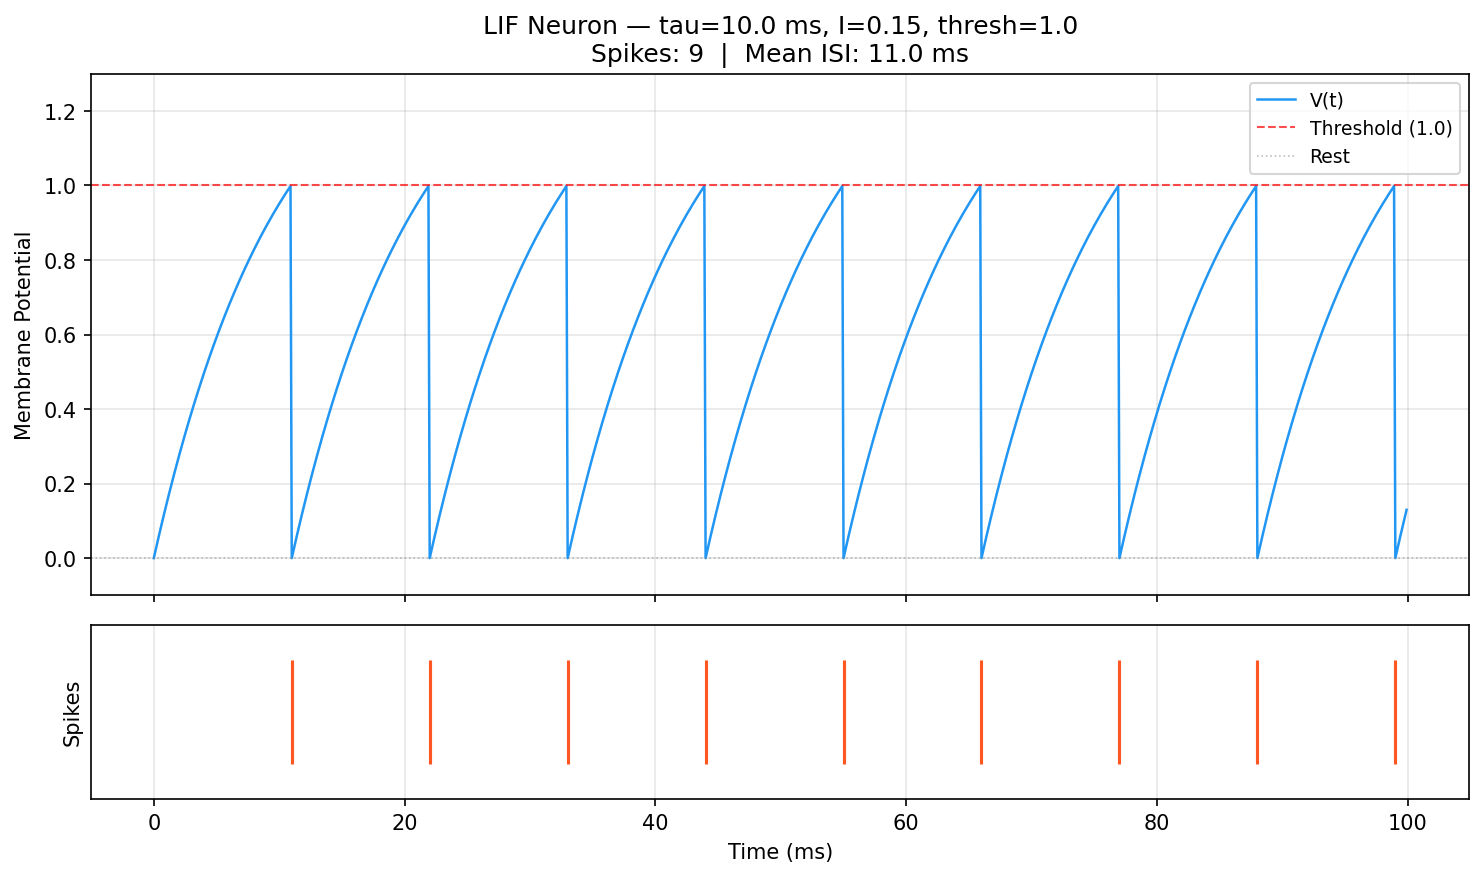

## Data Loading

One-time ODDS setup -- run locally before this cell:
```
python scripts/download_odds.py
# Then upload ./data_download/*.mat to Google Drive/SNN-Research/data/
```
NSL-KDD and SMAP download automatically.

In [6]:
# CELL 4 -- Load datasets
# Registry keys: 'thyroid', 'cardio', 'nslkdd', 'smap'
# thyroid  <- copy 38_thyroid.npz to Drive/SNN-Research/data/
# cardio   <- copy 7_Cardiotocography.npz to Drive/SNN-Research/data/
# nslkdd + smap download/build automatically
#
# To start without the ADBench files, use: DATASETS = ['nslkdd', 'smap']

DATASETS = ['thyroid', 'cardio', 'nslkdd', 'unswnb15']

dm = DataManager(data_dir=DATA_DIR)
dataset_splits = {}

for name in DATASETS:
    print(f'\n-- {name.upper()} --')
    try:
        X, y = dm.load(name)
        X_train, X_test, y_test = dm.split(X, y)
        tr_ld, te_ld = dm.dataloaders(X_train, X_test, batch_size=64)
        dataset_splits[name] = {
            'X_train': X_train, 'X_test': X_test, 'y_test': y_test,
            'tr_loader': tr_ld, 'te_loader': te_ld,
            'input_dim': X.shape[1],
        }
    except FileNotFoundError as e:
        print(e)

print(f'\nLoaded: {list(dataset_splits.keys())}')


-- THYROID --
[THYROID] 3772 samples | 6 features | anomaly rate: 2.5%
  Source : ODDS via ADBench (Han et al. NeurIPS 2022)
  Train :  2943 normal only
  Test  :   736 normal +    93 anomaly

-- CARDIO --
[CARDIO] 2114 samples | 21 features | anomaly rate: 22.0%
  Source : ODDS via ADBench (Han et al. NeurIPS 2022)
  Train :  1318 normal only
  Test  :   330 normal +   466 anomaly

-- NSLKDD --
[NSLKDD] 10000 samples | 38 features | anomaly rate: 46.5%
  Source : NSL-KDD (Tavallaee et al. 2009)
  Train :  4282 normal only
  Test  :  1071 normal +  4647 anomaly

-- UNSWNB15 --
  Loading UNSW-NB15 from unswnb15.csv...
  Raw shape: (82332, 45)
  UNSW-NB15: 50000 samples | 39 features | anomaly rate: 54.9%
[UNSWNB15] 50000 samples | 39 features | anomaly rate: 54.9%
  Source : UNSW-NB15 (Moustafa & Slay 2015)
  Train : 18041 normal only
  Test  :  4511 normal + 27448 anomaly

Loaded: ['thyroid', 'cardio', 'nslkdd', 'unswnb15']


In [ ]:
# CELL 5 -- Experiment configuration Hyperparameters and settings for the experiment. Edit these to adjust the model and training.
CFG = {
    'hidden_dim' : 64,
    'latent_dim' : 16,
    'T'          : 8,
    'tau'        : 2.0,
    'threshold'  : 0.5,
    'lr'         : 1e-3,
    'batch_size' : 64,
    'seeds'      : [0, 1, 2, 3, 4],
    'device'     : DEVICE,
}

# Per-dataset epoch counts — edit HERE only, never touch Cell 6
DATASET_EPOCHS = {
    'thyroid'  : 100,   # needs more epochs to converge
    'cardio'   : 50,    # converges at 50; more epochs hurt
    'nslkdd'   : 50,    # converges at 50
    'unswnb15' : 50,    # monitor first run
}

print('Config:')
for k, v in CFG.items():
    print(f'  {k:<14}: {v}')
print('\nPer-dataset epochs:')
for ds, ep in DATASET_EPOCHS.items():
    print(f'  {ds:<14}: {ep}')

Config:
  hidden_dim    : 64
  latent_dim    : 16
  T             : 8
  tau           : 2.0
  threshold     : 0.5
  lr            : 0.001
  batch_size    : 64
  seeds         : [0, 1, 2, 3, 4]
  device        : cuda

Per-dataset epochs:
  thyroid       : 100
  cardio        : 50
  nslkdd        : 50
  unswnb15      : 50


## Main Experiment

Expected runtime on T4 GPU (50 epochs x 5 seeds):
- thyroid: ~8 min | cardiotocography: ~5 min | nslkdd: ~15 min | smap: ~4 min

Results save to Drive after each dataset -- session crash loses at most one dataset.

In [ ]:
# CELL 6 -- Train SNN + ANN + baselines, multi-seed evaluation, and visualisations for each dataset. Saves results + figures to RESULTS_DIR.
all_results = {}

for ds_name, split in dataset_splits.items():
    print(f'\n{"="*65}')
    print(f'  DATASET: {ds_name.upper()}')
    print(f'{"="*65}')

    ds_dir = Path(RESULTS_DIR) / ds_name
    ds_dir.mkdir(parents=True, exist_ok=True)

    # ← NEW: read per-dataset epochs from Cell 5, never edit this line
    epochs = DATASET_EPOCHS.get(ds_name, 50)
    print(f'  Epochs : {epochs}')

    idim = split['input_dim']
    X_tr = split['X_train']
    X_te = split['X_test']
    y_te = split['y_test']

    snn_kw = dict(input_dim=idim, hidden_dim=CFG['hidden_dim'],
                  latent_dim=CFG['latent_dim'], T=CFG['T'],
                  tau=CFG['tau'], threshold=CFG['threshold'])
    ann_kw = dict(input_dim=idim, hidden_dim=CFG['hidden_dim'],
                  latent_dim=CFG['latent_dim'])

    # ← CHANGED: CFG['epochs'] → epochs (both lines)
    snn_fn = partial(train, epochs=epochs, lr=CFG['lr'],
                     log_every=epochs, is_snn=True)
    ann_fn = partial(train, epochs=epochs, lr=CFG['lr'],
                     log_every=epochs, is_snn=False)

    print('\nSNN (5 seeds)')
    snn_res = multi_seed_evaluate(
        SNNAutoencoder, snn_kw, X_tr, X_te, y_te,
        train_fn=snn_fn, device=CFG['device'],
        seeds=CFG['seeds'], batch_size=CFG['batch_size'], model_type='SNN')

    print('\nANN (5 seeds)')
    ann_res = multi_seed_evaluate(
        ANNAutoencoder, ann_kw, X_tr, X_te, y_te,
        train_fn=ann_fn, device=CFG['device'],
        seeds=CFG['seeds'], batch_size=CFG['batch_size'], model_type='ANN')

    print('\nClassical baselines')
    baseline_res = run_all_baselines(X_tr, X_te, y_te)

    # Seed-0 models for plots + checkpoints
    torch.manual_seed(0)
    snn_0 = SNNAutoencoder(**snn_kw).to(DEVICE)
    ann_0 = ANNAutoencoder(**ann_kw).to(DEVICE)
    tr_ld_0, te_ld_0 = dm.dataloaders(X_tr, X_te, batch_size=CFG['batch_size'])

    # ← CHANGED: CFG['epochs'] → epochs, log_every=10 → auto-scales
    snn_losses = train(snn_0, tr_ld_0, DEVICE, epochs, CFG['lr'],
                       log_every=max(1, epochs//10), is_snn=True)
    ann_losses = train(ann_0, tr_ld_0, DEVICE, epochs, CFG['lr'],
                       log_every=max(1, epochs//10), is_snn=False)

    torch.save(snn_0.state_dict(), str(ds_dir / 'snn_seed0.pt'))
    torch.save(ann_0.state_dict(), str(ds_dir / 'ann_seed0.pt'))

    plot_training_loss(snn_losses, ann_losses, ds_name, save_dir=str(ds_dir))

    for model, mname in [(snn_0, 'SNN'), (ann_0, 'ANN')]:
        tr_err = reconstruction_errors(model, tr_ld_0, DEVICE)
        te_err = reconstruction_errors(model, te_ld_0, DEVICE)
        thresh = optimal_threshold(tr_err)
        plot_error_distributions(tr_err, te_err, y_te, thresh, mname,
                                  save_dir=str(ds_dir))

    all_results[ds_name] = {'snn': snn_res, 'ann': ann_res, 'baselines': baseline_res}
    print_comparison(snn_res, ann_res, ds_name)
    print(f'Saved to: {ds_dir}')

# ← NEW: save results JSON + comparison plot at end
import json
def _serialisable(obj):
    if isinstance(obj, (np.integer, np.floating)): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, dict): return {k: _serialisable(v) for k, v in obj.items()}
    if isinstance(obj, list): return [_serialisable(i) for i in obj]
    return obj

results_path = Path(RESULTS_DIR) / 'results.json'
with open(results_path, 'w') as f:
    json.dump(_serialisable(all_results), f, indent=2)

fig_path = plot_comparison(all_results, save_dir=RESULTS_DIR)
print(f'\nMain experiment complete.')
print(f'Results JSON : {results_path}')
print(f'Figure       : {fig_path}')
plt.show()


  DATASET: THYROID
  Epochs : 100

SNN (5 seeds)
  Epoch    1/100  loss=0.092891
  Epoch  100/100  loss=0.000540
  seed=0 | F1=0.7923 | AUC=0.9683
  Epoch    1/100  loss=0.087031
  Epoch  100/100  loss=0.000558
  seed=1 | F1=0.7200 | AUC=0.9638
  Epoch    1/100  loss=0.095984
  Epoch  100/100  loss=0.000537
  seed=2 | F1=0.7545 | AUC=0.9724
  Epoch    1/100  loss=0.091672
  Epoch  100/100  loss=0.000527
  seed=3 | F1=0.7678 | AUC=0.9717
  Epoch    1/100  loss=0.099940
  Epoch  100/100  loss=0.000587
  seed=4 | F1=0.7512 | AUC=0.9636

ANN (5 seeds)
  Epoch    1/100  loss=0.044879
  Epoch  100/100  loss=0.000028
  seed=0 | F1=0.8257 | AUC=0.9934
  Epoch    1/100  loss=0.054550
  Epoch  100/100  loss=0.000031
  seed=1 | F1=0.8108 | AUC=0.9928
  Epoch    1/100  loss=0.079558
  Epoch  100/100  loss=0.000028
  seed=2 | F1=0.8219 | AUC=0.9928
  Epoch    1/100  loss=0.099871
  Epoch  100/100  loss=0.031701
  seed=3 | F1=0.0889 | AUC=0.5116
  Epoch    1/100  loss=0.021480
  Epoch  100/100  los

## =================================================================
##  DATASET: THYROID

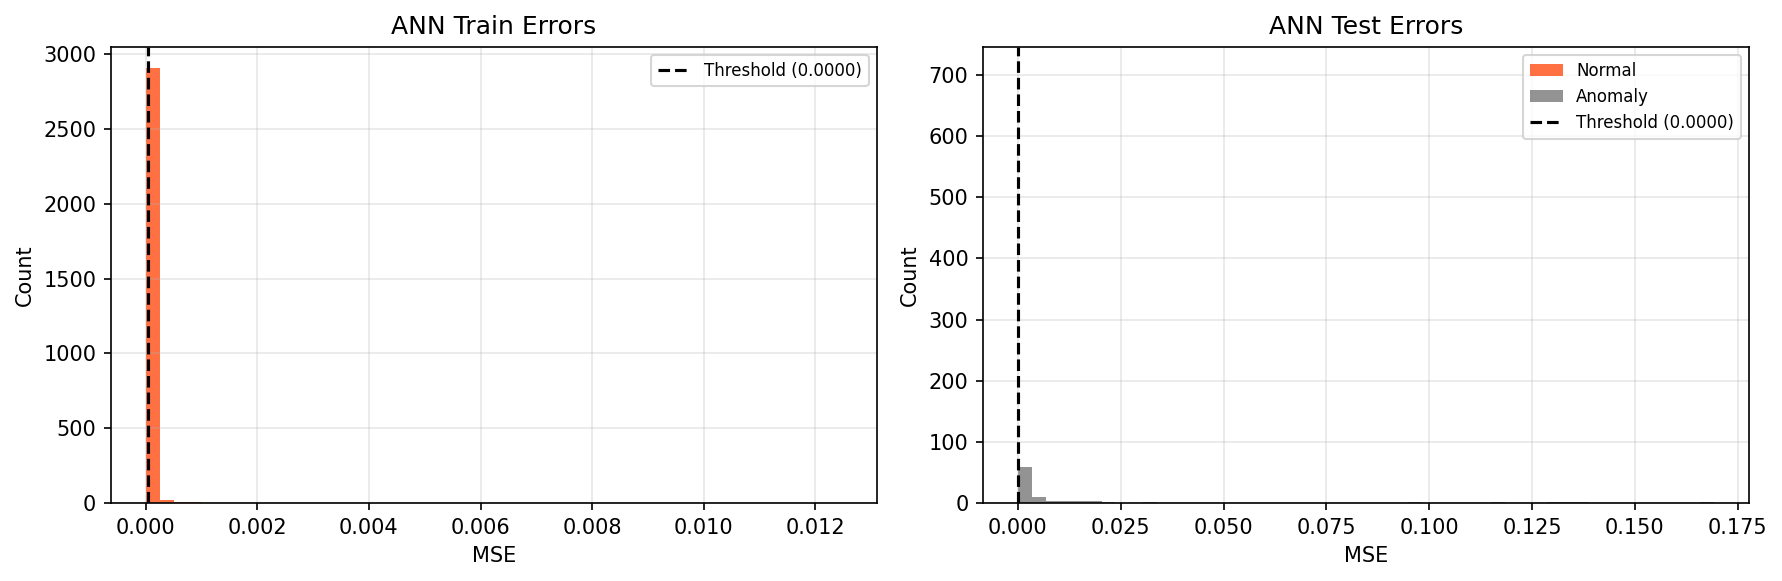

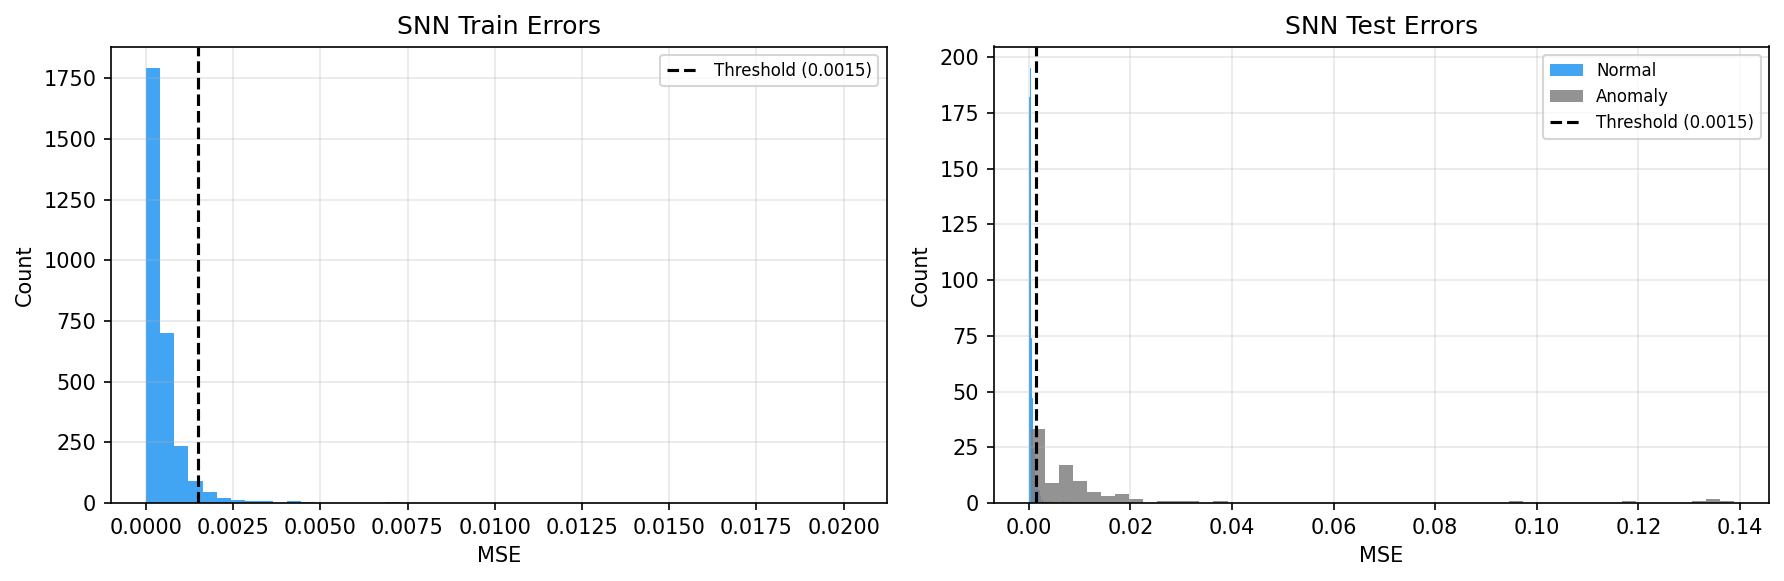

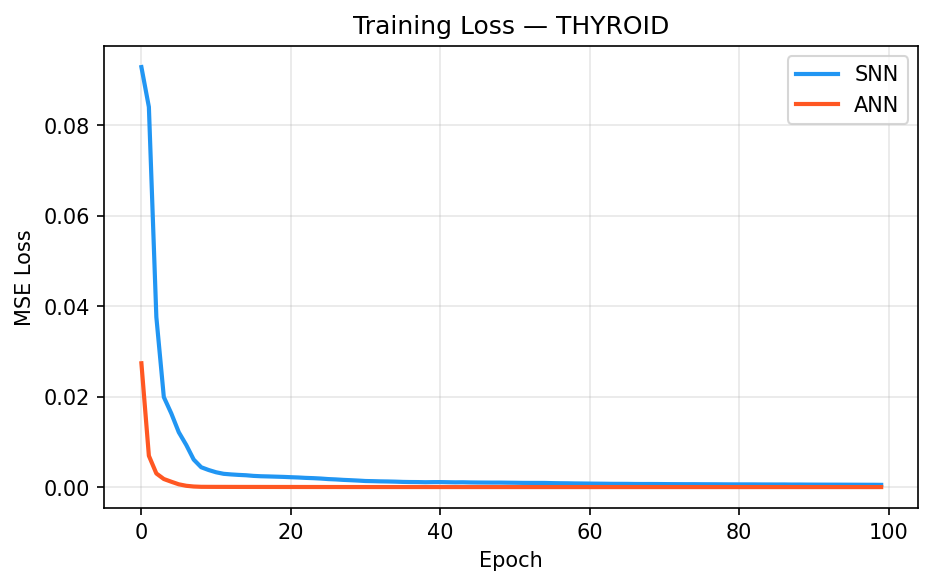

## =================================================================

##  DATASET: CARDIO

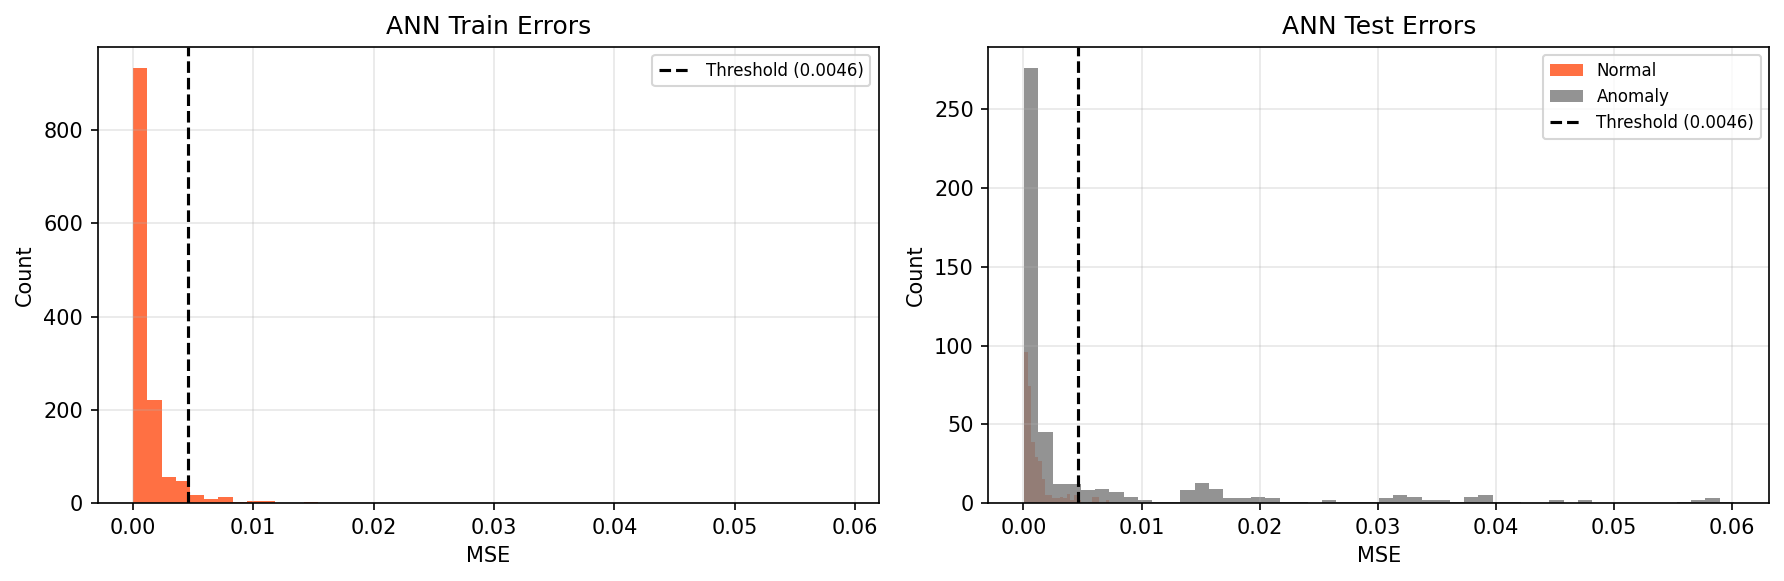

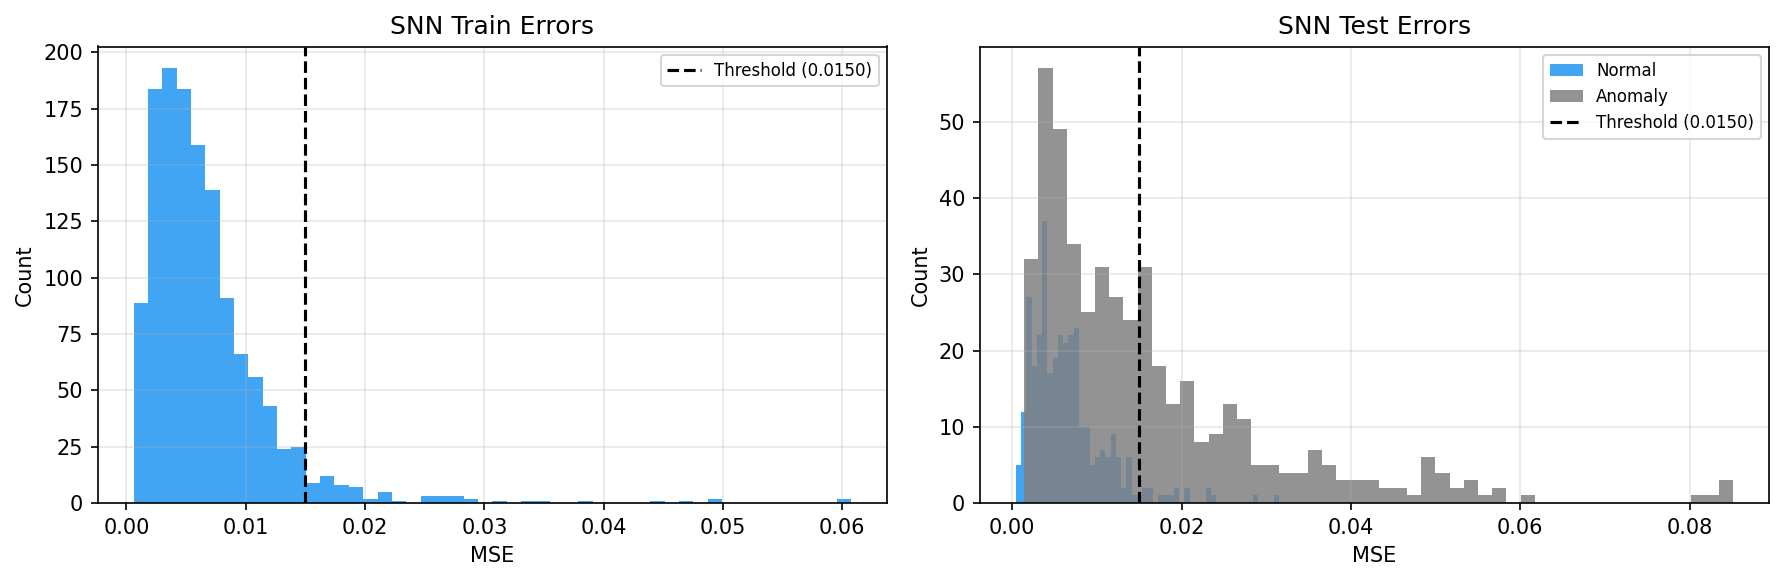

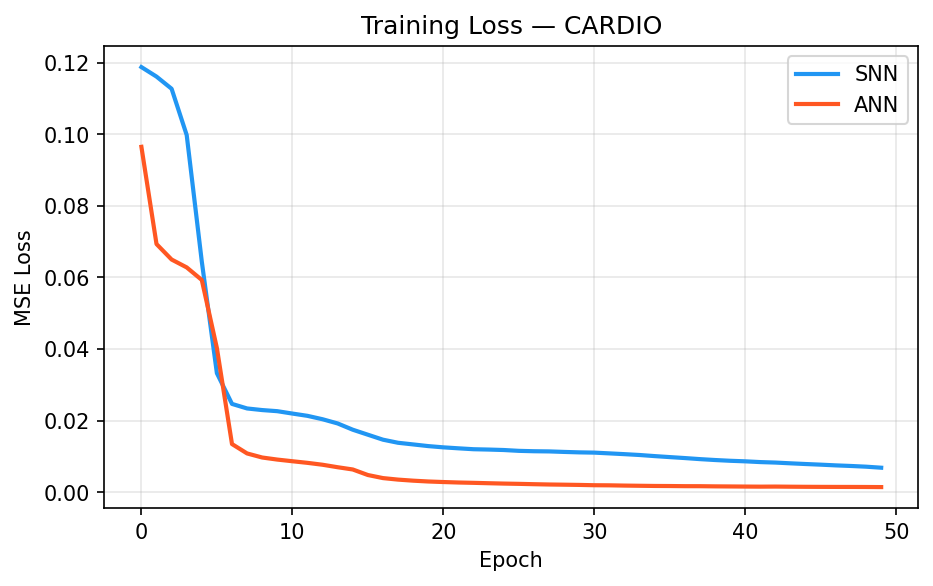

## =================================================================

##  DATASET: NSLKDD

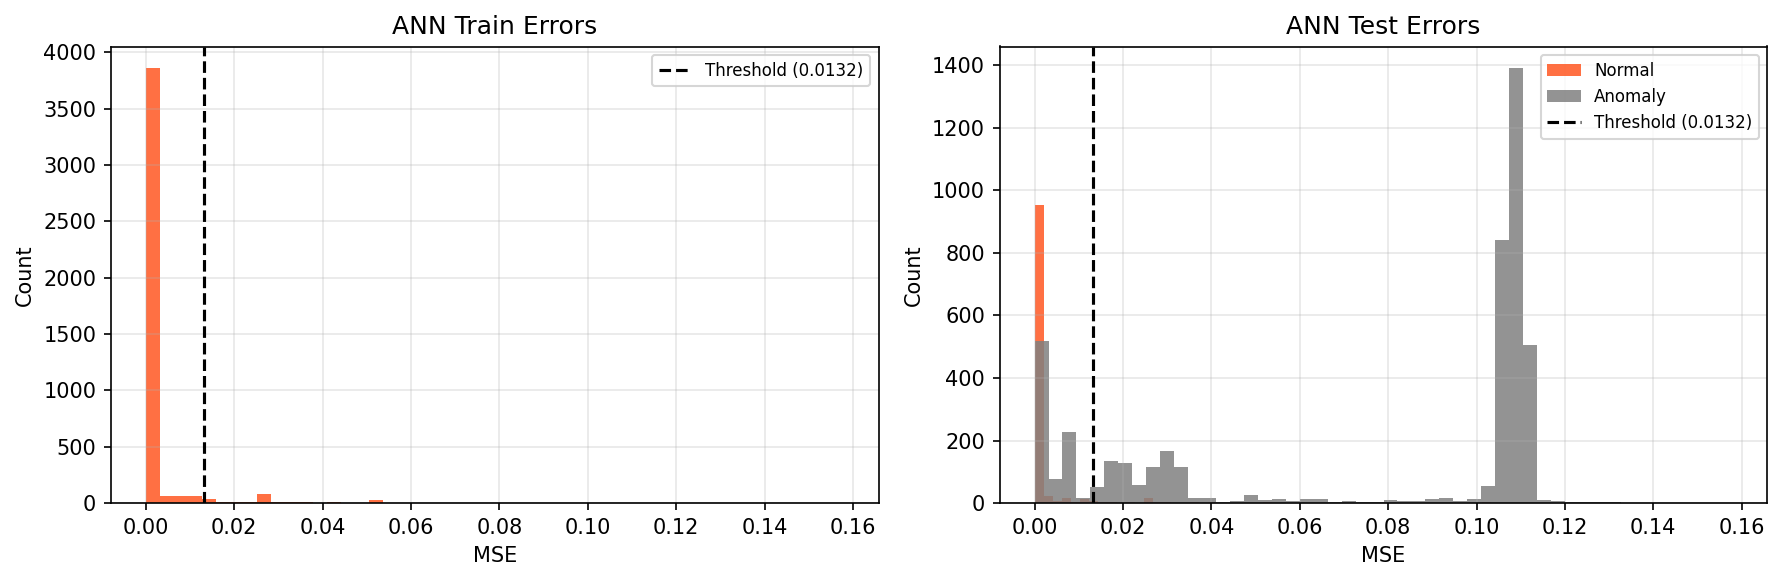

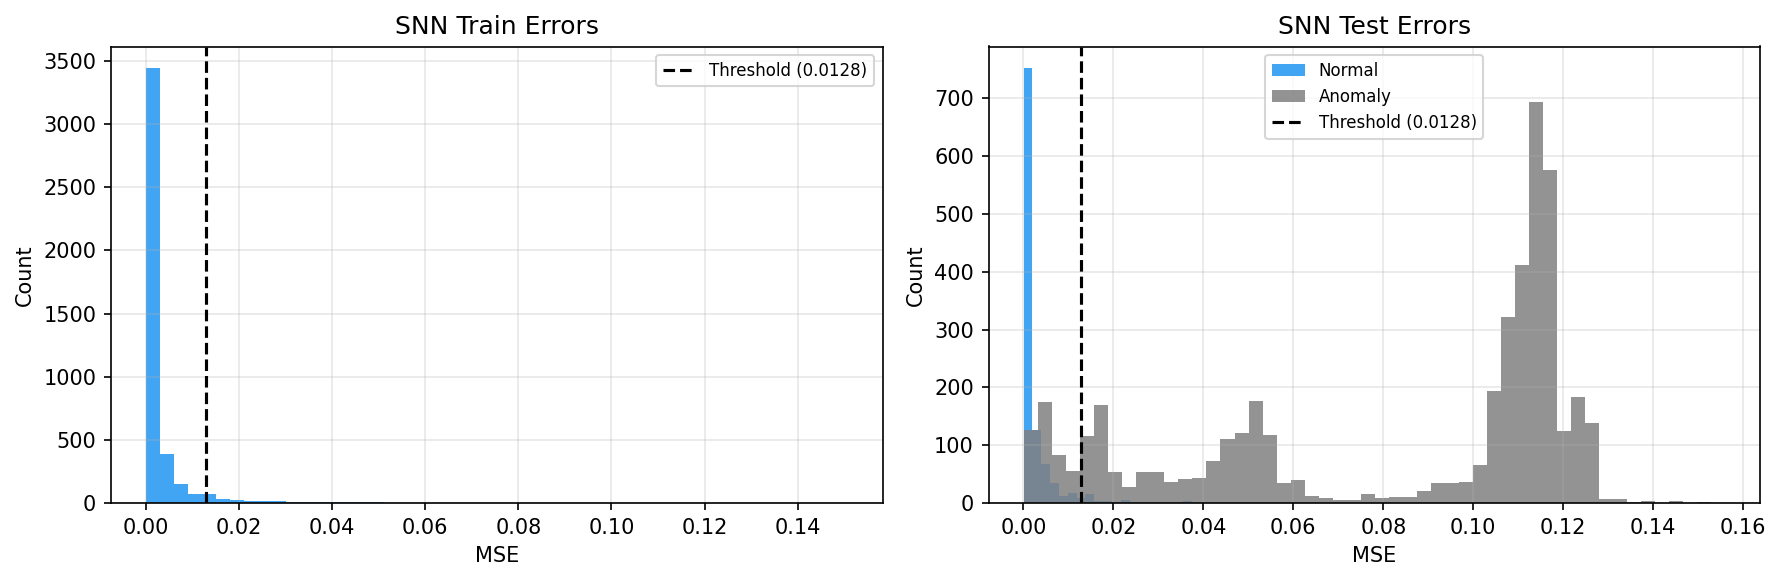

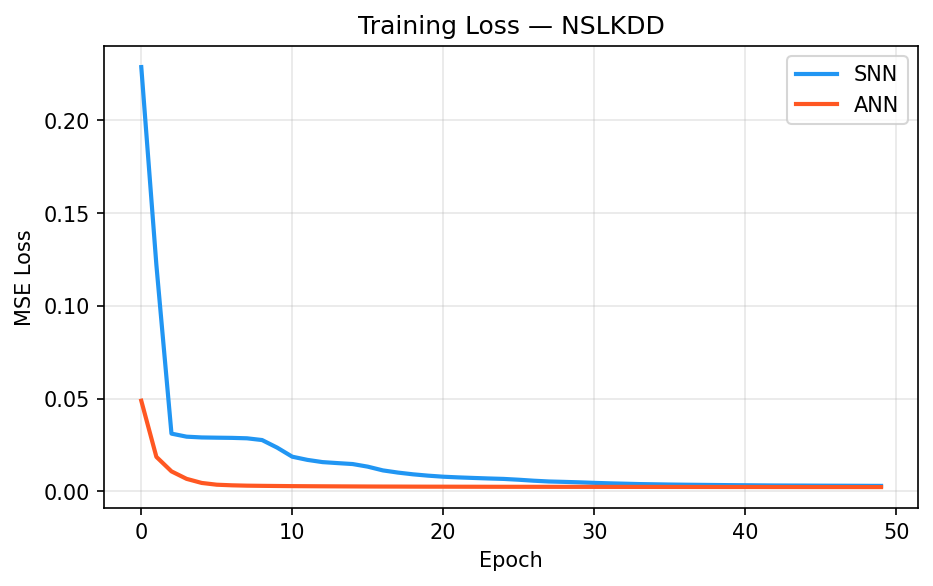

## =================================================================

##   DATASET: UNSWNB15

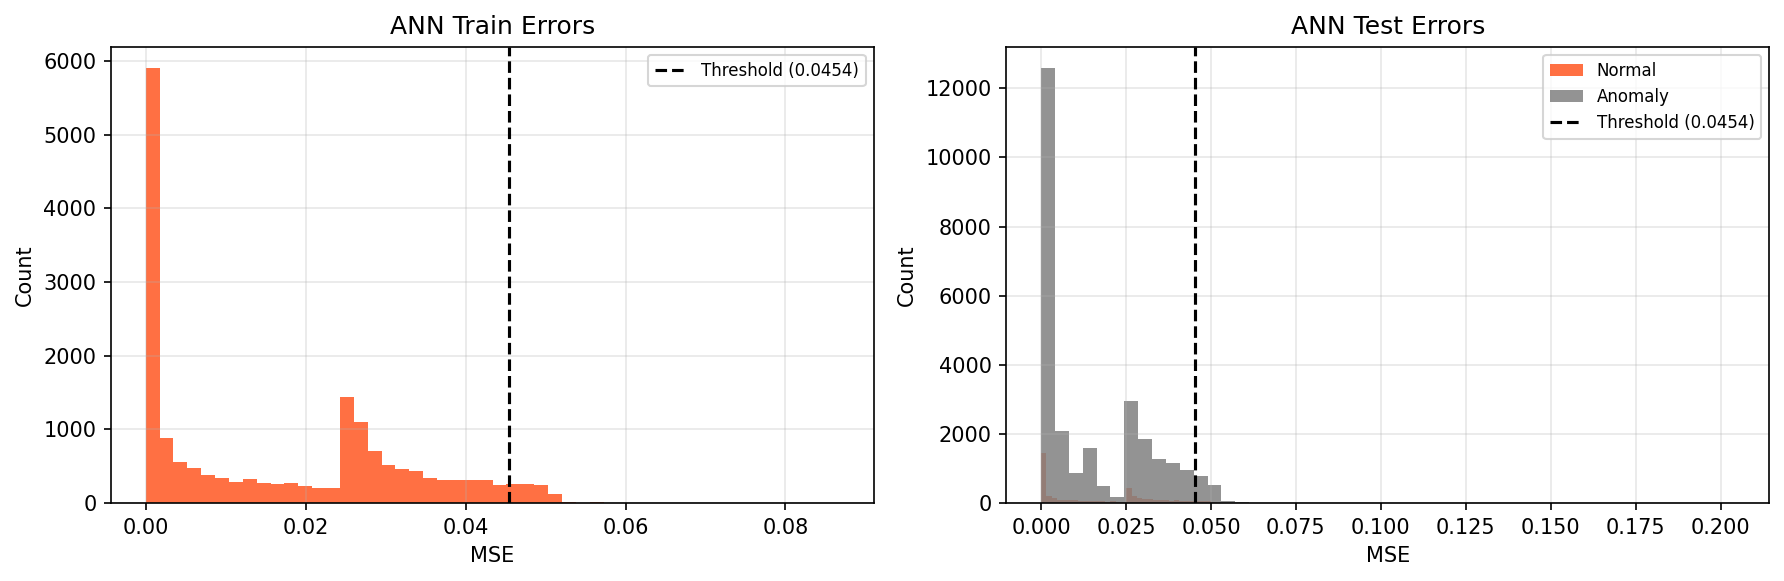

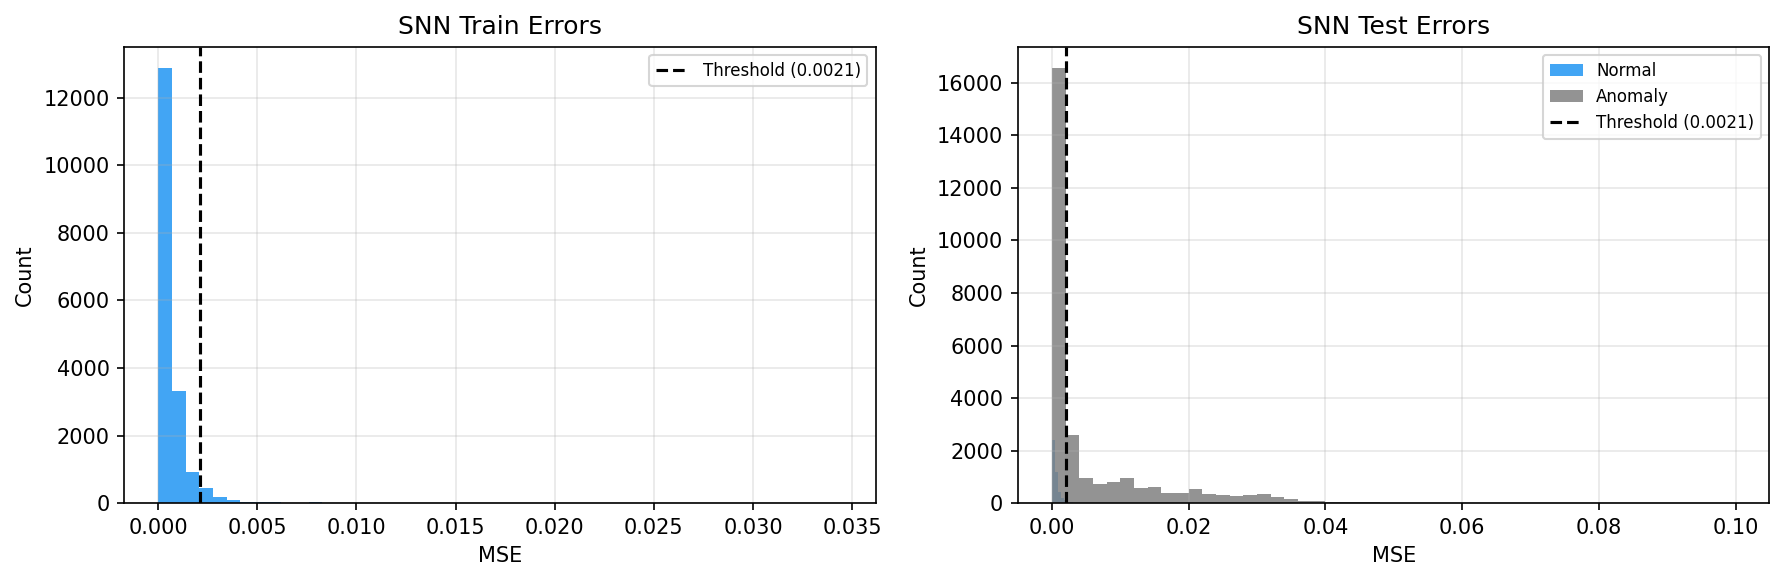

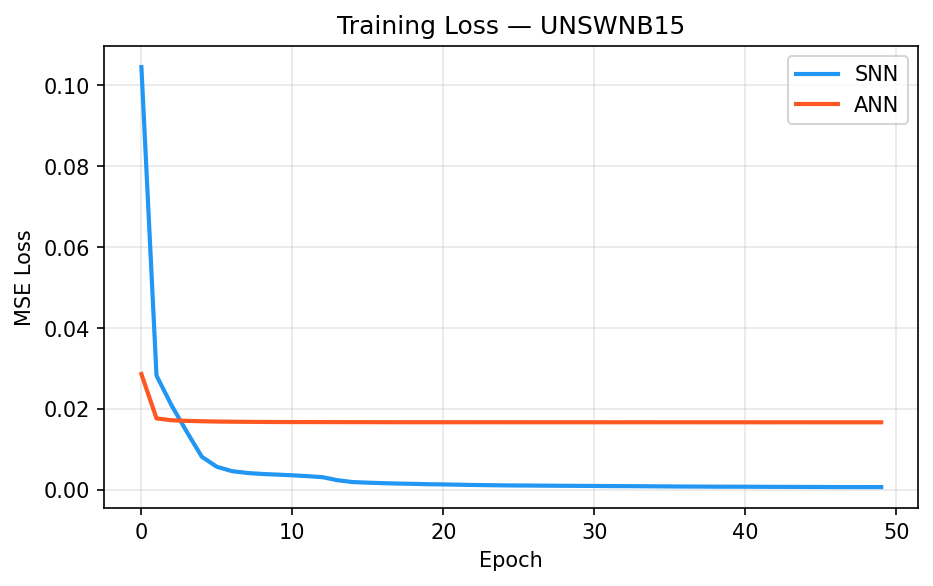

## =================================================================


In [ ]:
# CELL 7 -- Save results.json + comparison figure for all datasets. This is separate from Cell 6 to ensure it runs even if some datasets fail.

def _serialisable(obj):
    if isinstance(obj, dict):
        return {k: _serialisable(v) for k, v in obj.items()
                if not isinstance(v, np.ndarray)}
    if isinstance(obj, list):
        return [_serialisable(i) for i in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return float(obj)
    return obj

results_path = Path(RESULTS_DIR) / 'results.json'
with open(results_path, 'w') as f:
    json.dump(_serialisable(all_results), f, indent=2)
print(f'Results JSON : {results_path}')

fig_path = plot_comparison(all_results, save_dir=RESULTS_DIR)
print(f'Figure       : {fig_path}')
plt.show()

Results JSON : C:\Capstone\Experiment SNN-Abnormality-Detection\results\results.json
Figure       : C:\Capstone\Experiment SNN-Abnormality-Detection\results\comparison_all_datasets.png


## comparison_all_datasets

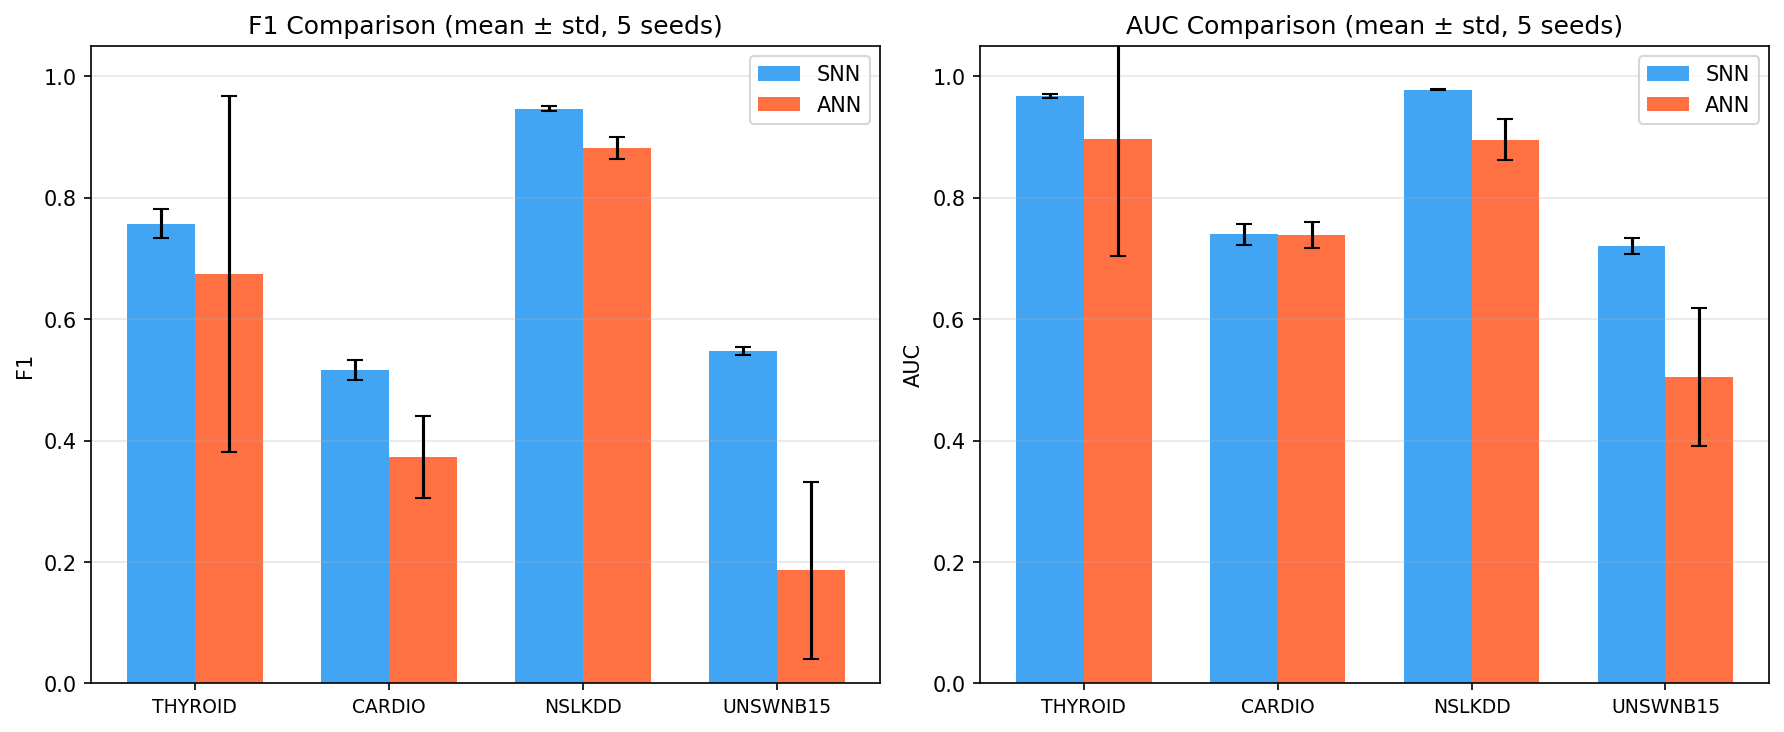

## Research Finding 1 -- T-Sensitivity Pareto Frontier

Sweeps T in {4, 8, 16, 32} across all datasets.
Each T value is one point on the accuracy-energy tradeoff curve.
This is the primary novel contribution & finding for this research.

Runtime: ~3 hours total on 4070 Gpu (3 seeds x 4 T-values x 4 datasets)

In [ ]:
# CELL 8 -- T-sensitivity sweep for SNNs. Trains and evaluates SNNs with T=4,8,16,32 on all datasets, then plots F1 vs T and energy vs T curves.

T_VALUES   = [4, 8, 16, 32]
T_SEEDS    = [0, 1, 2]
T_DATASETS = list(dataset_splits.keys())
# For a quick test run:
#   T_DATASETS = ['nslkdd']

t_sensitivity_results = {}

for ds_name in T_DATASETS:
    split = dataset_splits[ds_name]
    print(f'\nT-sensitivity: {ds_name.upper()}')
    t_sensitivity_results[ds_name] = {}

    for T in T_VALUES:
        print(f'  T = {T}')
        snn_kw_t = dict(
            input_dim=split['input_dim'],
            hidden_dim=CFG['hidden_dim'], latent_dim=CFG['latent_dim'],
            T=T, tau=CFG['tau'], threshold=CFG['threshold'])
        epochs_t = DATASET_EPOCHS.get(ds_name, 50)
        train_fn_t = partial(train, epochs=epochs_t, lr=CFG['lr'],
                     log_every=epochs_t, is_snn=True)
        t_res = multi_seed_evaluate(
            SNNAutoencoder, snn_kw_t,
            split['X_train'], split['X_test'], split['y_test'],
            train_fn=train_fn_t, device=CFG['device'],
            seeds=T_SEEDS, batch_size=CFG['batch_size'], model_type='SNN')

        t_sensitivity_results[ds_name][T] = t_res
        f1_m = t_res.get('f1_mean', 0)
        f1_s = t_res.get('f1_std',  0)
        e_m  = t_res.get('energy_nJ_projected_mean', 0)
        print(f'    F1={f1_m:.4f}+-{f1_s:.4f} | E={e_m:.5f} nJ (Loihi2-proj)')

    fig_path = plot_t_sensitivity(t_sensitivity_results[ds_name],
                                   ds_name, save_dir=RESULTS_DIR)
    print(f'  Saved: {fig_path}')
    plt.show()

t_path = Path(RESULTS_DIR) / 't_sensitivity.json'
with open(t_path, 'w') as f:
    json.dump(_serialisable(t_sensitivity_results), f, indent=2)
print(f'\nT-sensitivity JSON: {t_path}')


T-sensitivity: THYROID
  T = 4
  Epoch    1/100  loss=0.092891
  Epoch  100/100  loss=0.000679
  seed=0 | F1=0.7207 | AUC=0.9660
  Epoch    1/100  loss=0.087031
  Epoch  100/100  loss=0.000636
  seed=1 | F1=0.7149 | AUC=0.9588
  Epoch    1/100  loss=0.095984
  Epoch  100/100  loss=0.000673
  seed=2 | F1=0.7182 | AUC=0.9477
    F1=0.7179+-0.0024 | E=0.01940 nJ (Loihi2-proj)
  T = 8
  Epoch    1/100  loss=0.092891
  Epoch  100/100  loss=0.000540
  seed=0 | F1=0.7923 | AUC=0.9683
  Epoch    1/100  loss=0.087031
  Epoch  100/100  loss=0.000558
  seed=1 | F1=0.7200 | AUC=0.9638
  Epoch    1/100  loss=0.095984
  Epoch  100/100  loss=0.000537
  seed=2 | F1=0.7545 | AUC=0.9724
    F1=0.7556+-0.0295 | E=0.03908 nJ (Loihi2-proj)
  T = 16
  Epoch    1/100  loss=0.092891
  Epoch  100/100  loss=0.000506
  seed=0 | F1=0.7273 | AUC=0.9666
  Epoch    1/100  loss=0.087031
  Epoch  100/100  loss=0.000518
  seed=1 | F1=0.7442 | AUC=0.9646
  Epoch    1/100  loss=0.095984
  Epoch  100/100  loss=0.000527
 

## Visualisation Finding 1: T-Sensitivity

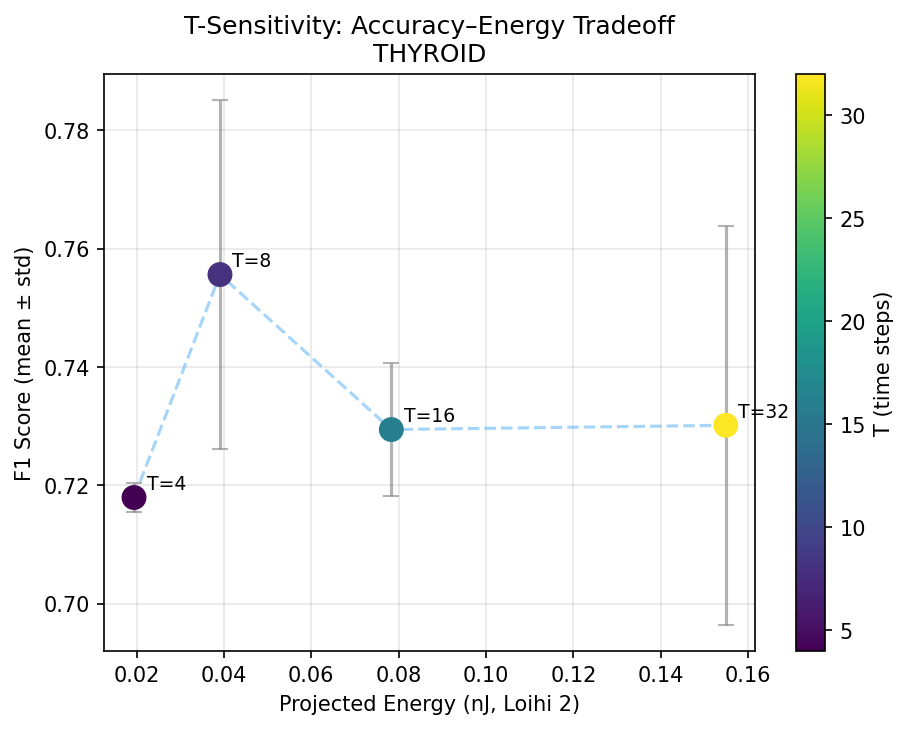

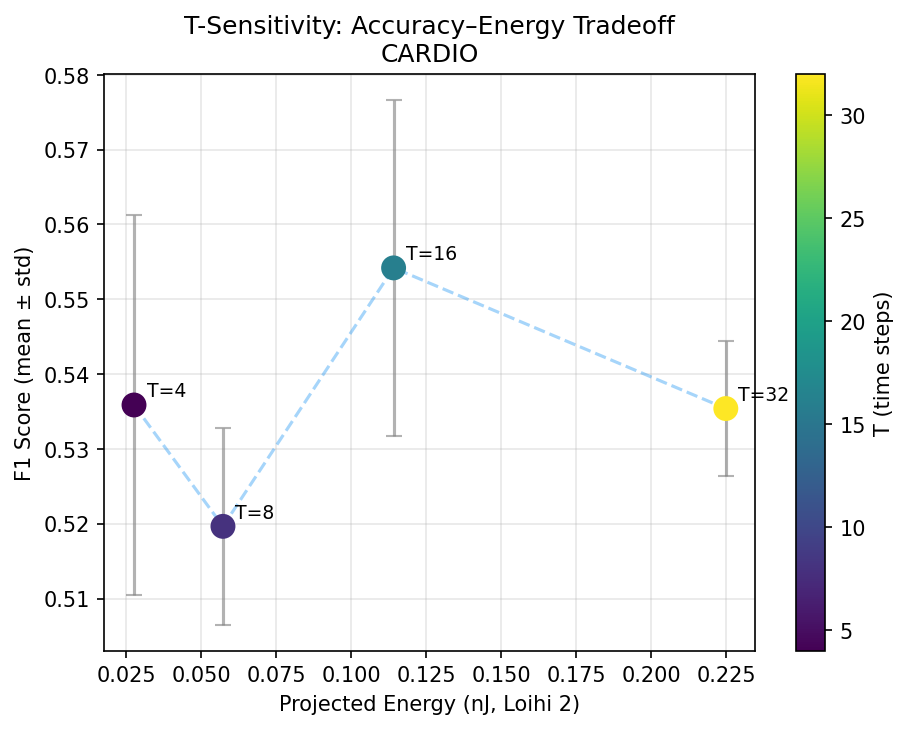

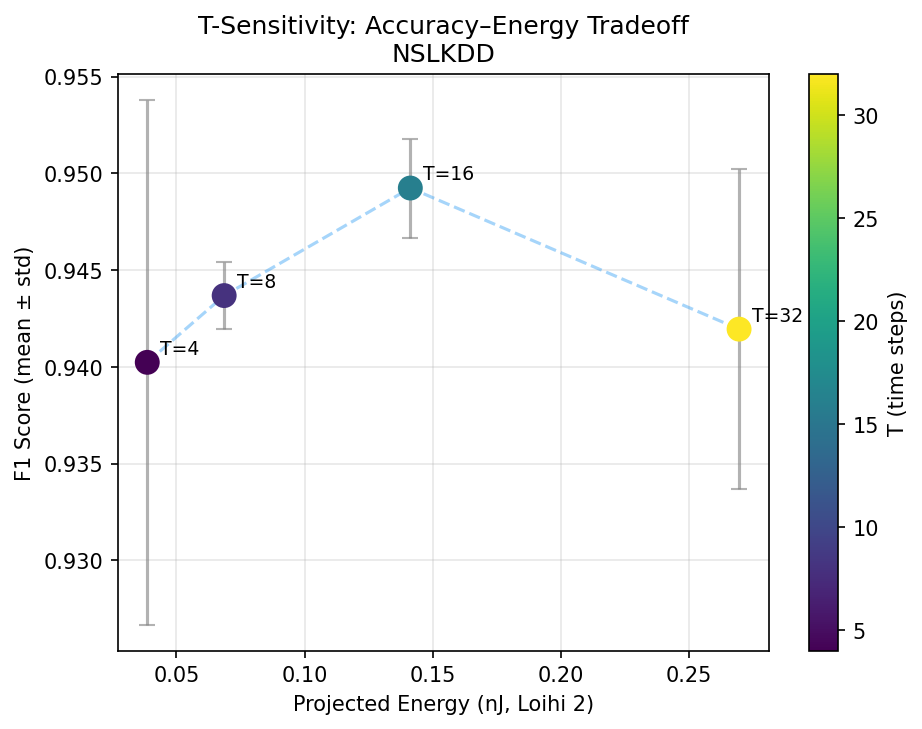

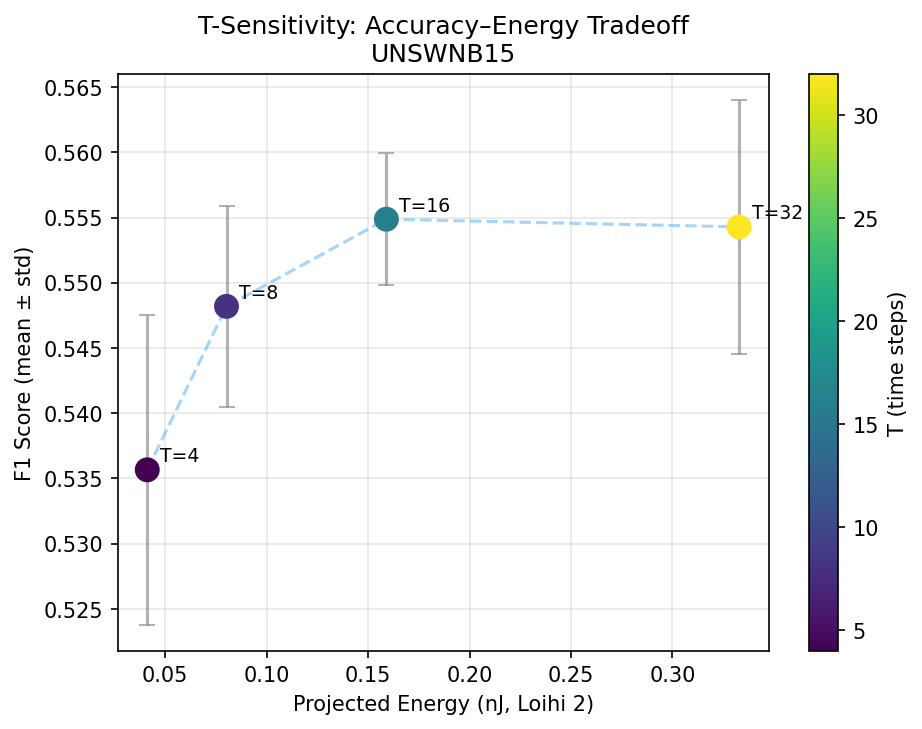

## Research Finding 2 -- Spike Sparsity Analysis

Measures per-layer firing rates.
Silent neurons cost zero energy on neuromorphic hardware.
This is the mechanistic explanation behind the energy projections.

In [ ]:
# CELL 9 -- Spike sparsity analysis for the trained SNNs. Loads the seed-0 SNN for each dataset, computes average firing rates per layer on the test set, and plots sparsity.

sparsity_by_dataset = {}

for ds_name, split in dataset_splits.items():
    ckpt = Path(RESULTS_DIR) / ds_name / 'snn_seed0.pt'
    if not ckpt.exists():
        print(f'No checkpoint for {ds_name} -- run Cell 6 first')
        continue

    snn_sp = SNNAutoencoder(
        input_dim=split['input_dim'],
        hidden_dim=CFG['hidden_dim'], latent_dim=CFG['latent_dim'],
        T=CFG['T'], tau=CFG['tau'], threshold=CFG['threshold']
    ).to(DEVICE)
    snn_sp.load_state_dict(torch.load(str(ckpt), map_location=DEVICE))
    snn_sp.eval()

    layer_acc = {'enc_hidden': [], 'enc_latent': [], 'dec_hidden': []}
    for (batch,) in split['te_loader']:
        rates = snn_sp.spike_rates(batch.to(DEVICE))
        for k in layer_acc:
            layer_acc[k].append(rates[k])

    mean_rates = {k: float(np.mean(v)) for k, v in layer_acc.items()}
    sparsity_by_dataset[ds_name] = mean_rates
    overall = np.mean(list(mean_rates.values()))

    print(f'[{ds_name.upper()}]')
    for layer, rate in mean_rates.items():
        print(f'  {layer:<14}: {rate:.1%} firing  ({1-rate:.1%} silent)')
    print(f'  Overall    : {overall:.1%} firing -- '
          f'{1-overall:.1%} silent (zero energy on Loihi)\n')

if sparsity_by_dataset:
    fig_path = plot_sparsity(sparsity_by_dataset, save_dir=RESULTS_DIR)
    print(f'Saved: {fig_path}')
    plt.show()

[THYROID]
  enc_hidden    : 29.9% firing  (70.1% silent)
  enc_latent    : 60.8% firing  (39.2% silent)
  dec_hidden    : 39.4% firing  (60.6% silent)
  Overall    : 43.4% firing -- 56.6% silent (zero energy on Loihi)

[CARDIO]
  enc_hidden    : 40.7% firing  (59.3% silent)
  enc_latent    : 62.7% firing  (37.3% silent)
  dec_hidden    : 35.8% firing  (64.2% silent)
  Overall    : 46.4% firing -- 53.6% silent (zero energy on Loihi)

[NSLKDD]
  enc_hidden    : 46.1% firing  (53.9% silent)
  enc_latent    : 47.1% firing  (52.9% silent)
  dec_hidden    : 35.0% firing  (65.0% silent)
  Overall    : 42.7% firing -- 57.3% silent (zero energy on Loihi)

[UNSWNB15]
  enc_hidden    : 47.8% firing  (52.2% silent)
  enc_latent    : 59.7% firing  (40.3% silent)
  dec_hidden    : 51.6% firing  (48.4% silent)
  Overall    : 53.0% firing -- 47.0% silent (zero energy on Loihi)

Saved: C:\Capstone\Experiment SNN-Abnormality-Detection\results\sparsity_analysis.png


## Visualisation of Sparsity Analysis

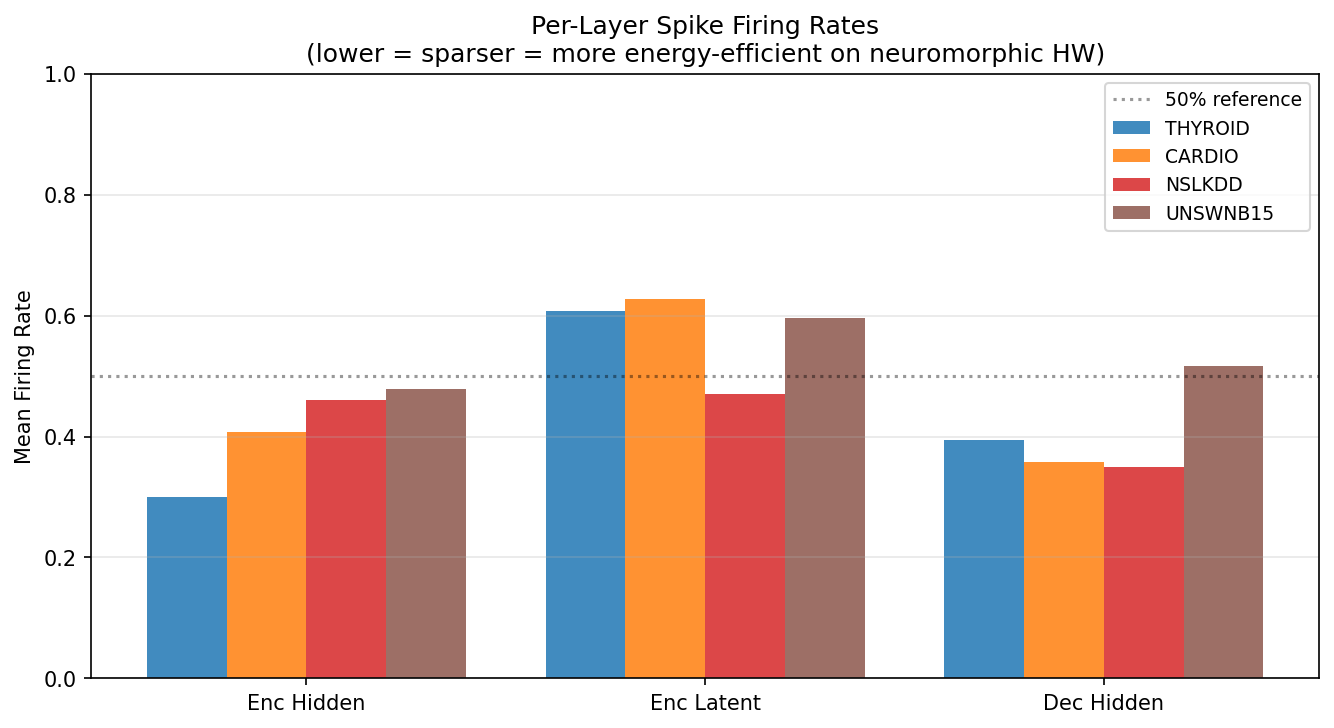


In [ ]:
# CELL 10 -- Final summary table (paper-ready) and notes on energy calculations.

def g(r, k, fb=0):  return r.get(f'{k}_mean', r.get(k, fb))
def gs(r, k):       return r.get(f'{k}_std', 0)

W = 82
print('\n' + '='*W)
print(f'{"FINAL RESULTS (mean +/- std, 5 seeds)":^{W}}')
print('='*W)
print(f'{"Dataset":<20} {"Model":<12} {"F1":>13} {"AUC":>13} '
      f'{"Energy":>16} {"Lat(ms)":>9}')
print('-'*W)

for ds, res in all_results.items():
    snn = res['snn']
    ann = res['ann']
    bsl = res['baselines']

    snn_e = g(snn, 'energy_nJ_projected')
    ann_e = g(ann, 'energy_nJ_actual')
    ratio = ann_e / (snn_e + 1e-12)

    print(f'{ds:<20} {"SNN":<12} '
          f'{g(snn,"f1"):>6.4f}+-{gs(snn,"f1"):>6.4f} '
          f'{g(snn,"auc"):>6.4f}+-{gs(snn,"auc"):>6.4f} '
          f'{snn_e:>9.5f} nJ* '
          f'{g(snn,"latency_ms"):>7.2f}')
    print(f'{"":<20} {"ANN":<12} '
          f'{g(ann,"f1"):>6.4f}+-{gs(ann,"f1"):>6.4f} '
          f'{g(ann,"auc"):>6.4f}+-{gs(ann,"auc"):>6.4f} '
          f'{ann_e:>9.5f} nJ  '
          f'{g(ann,"latency_ms"):>7.2f}')
    for bname, br in bsl.items():
        print(f'{"":<20} {bname:<12} '
              f'{br["f1"]:>6.4f}  n/a  '
              f'{br["auc"]:>6.4f}  n/a')
    print(f'  Energy reduction (projected): {ratio:.1f}x')
    print('-'*W)

print()
print('* SNN energy: Loihi 2 projection  (4.6 fJ/SynOp, Davies et al. 2021)')
print('  ANN energy: GPU estimate         (200 fJ/FLOP,  Horowitz 2014)')
print('  Direct on-hardware measurement is future work.')


                      FINAL RESULTS (mean +/- std, 5 seeds)                       
Dataset              Model                   F1           AUC           Energy   Lat(ms)
----------------------------------------------------------------------------------
thyroid              SNN          0.7572+-0.0235 0.9680+-0.0037   0.03876 nJ*    6.39
                     ANN          0.6746+-0.2929 0.8966+-0.1925   0.56320 nJ     0.27
                     IsoForest    0.6996  n/a  0.9861  n/a
                     OCSVM        0.6916  n/a  0.9627  n/a
                     LOF          0.7745  n/a  0.9767  n/a
  Energy reduction (projected): 14.5x
----------------------------------------------------------------------------------
cardio               SNN          0.5160+-0.0161 0.7398+-0.0171   0.05817 nJ*    7.82
                     ANN          0.3728+-0.0670 0.7383+-0.0214   0.94720 nJ     0.34
                     IsoForest    0.6119  n/a  0.8457  n/a
                     OCSVM        0.6241  n

Dataset           3.2 fJ/SynOp      4.6 fJ/SynOp      6.0 fJ/SynOp
-----------------------------------------------------------------
thyroid                 20.9×            14.5×            11.1×
cardio                  23.4×            16.3×            12.5×
nslkdd                  28.0×            19.5×            14.9×
unswnb15                23.9×            16.6×            12.8×

Figure saved: C:\Capstone\Experiment-SNN-Abnormality-Detection\results\energy_sensitivity_analysis.png


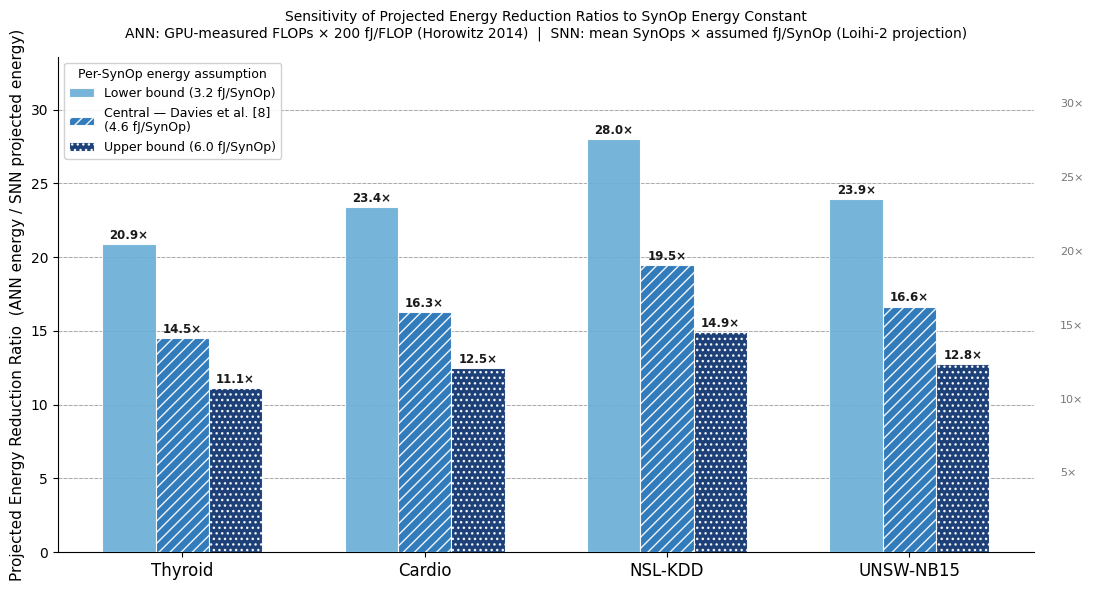

In [3]:
# ── Fixed standalone energy sensitivity figure ───────────────────────────────
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR  = r'C:\Capstone\Experiment-SNN-Abnormality-Detection\results'
results_path = Path(RESULTS_DIR) / 'results.json'

with open(results_path, 'r') as f:
    all_results = json.load(f)

DATASETS       = ['thyroid', 'cardio', 'nslkdd', 'unswnb15']
DATASET_LABELS = ['Thyroid', 'Cardio', 'NSL-KDD', 'UNSW-NB15']

CONSTANTS = {
    'Lower bound (3.2 fJ/SynOp)'                    : 3.2,
    'Central — Davies et al. [8]\n(4.6 fJ/SynOp)'  : 4.6,
    'Upper bound (6.0 fJ/SynOp)'                    : 6.0,
}

synops   = {}
ann_e_nJ = {}

for ds in DATASETS:
    synops[ds]   = all_results[ds]['snn']['synops_per_sample_mean']
    ann_e_nJ[ds] = all_results[ds]['ann']['energy_nJ_actual_mean']

# ── Compute ratios — FIXED unit conversion fJ → nJ = 1e-6 ───────────────────
ratios = {}
print(f'{"Dataset":<12}', end='')
for label in CONSTANTS:
    short = label.split('(')[1].replace(')', '').strip()
    print(f'  {short:>16}', end='')
print()
print('-' * 65)

for ds in DATASETS:
    ratios[ds] = []
    print(f'{ds:<12}', end='')
    for label, const_fJ in CONSTANTS.items():
        snn_e_nJ = synops[ds] * const_fJ * 1e-6   # fJ to nJ: multiply by 1e-6
        ratio    = ann_e_nJ[ds] / snn_e_nJ
        ratios[ds].append(ratio)
        print(f'  {ratio:>14.1f}×', end='')
    print()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

x       = np.arange(len(DATASETS))
width   = 0.22
offsets = [-width, 0, width]
colors  = ['#6BAED6', '#2171B5', '#08306B']
hatches = ['', '///', '...']

for i, (label, const_fJ) in enumerate(CONSTANTS.items()):
    vals = [ratios[ds][i] for ds in DATASETS]
    bars = ax.bar(
        x + offsets[i],
        vals,
        width      = width,
        color      = colors[i],
        hatch      = hatches[i],
        edgecolor  = 'white',
        linewidth  = 0.8,
        label      = label,
        zorder     = 3,
        alpha      = 0.92,
    )
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            f'{v:.1f}×',
            ha         = 'center',
            va         = 'bottom',
            fontsize   = 8.5,
            fontweight = 'bold',
            color      = '#1a1a1a',
        )

# Reference lines
all_vals  = [ratios[ds][i] for ds in DATASETS for i in range(3)]
max_ratio = max(all_vals) * 1.20

for ref, label_text in [(5, '5×'), (10, '10×'), (15, '15×'),
                         (20, '20×'), (25, '25×'), (30, '30×')]:
    if ref < max_ratio:
        ax.axhline(
            ref,
            color     = '#aaaaaa',
            linewidth = 0.7,
            linestyle = '--',
            zorder    = 2,
        )
        ax.text(
            len(DATASETS) - 0.38,
            ref + 0.15,
            label_text,
            fontsize = 8,
            color    = '#777777',
        )

ax.set_xticks(x)
ax.set_xticklabels(DATASET_LABELS, fontsize=12)
ax.set_ylabel(
    'Projected Energy Reduction Ratio  (ANN energy / SNN projected energy)',
    fontsize=11
)
ax.set_title(
    'Sensitivity of Projected Energy Reduction Ratios to SynOp Energy Constant\n'
    'ANN: GPU-measured FLOPs × 200 fJ/FLOP (Horowitz 2014)  |  '
    'SNN: mean SynOps × assumed fJ/SynOp (Loihi-2 projection)',
    fontsize=10,
    pad=14,
)
ax.set_ylim(0, max_ratio)
ax.legend(
    title          = 'Per-SynOp energy assumption',
    title_fontsize = 9,
    fontsize       = 9,
    loc            = 'upper left',
    framealpha     = 0.9,
    edgecolor      = '#cccccc',
)
ax.grid(axis='y', alpha=0.25, zorder=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

fig_path = Path(RESULTS_DIR) / 'energy_sensitivity_analysis.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'\nFigure saved: {fig_path}')
plt.show()